In [27]:
# Install the library
# %pip install pythae

In [28]:
import torch
import torchvision.datasets as datasets

device = "cuda" if torch.cuda.is_available() else "cpu"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
mnist_trainset = datasets.MNIST(root='../../data', train=True, download=True, transform=None)

train_dataset = mnist_trainset.data[:-10000].reshape(-1, 1, 28, 28) / 255.0
eval_dataset = mnist_trainset.data[-10000:].reshape(-1, 1, 28, 28) / 255.0

# train_dataset = train_dataset.float()
# eval_dataset = eval_dataset.float()


In [30]:
from pythae.models import AmortizedDualVAE, AmortizedDualVAEConfig
from pythae.trainers import BaseTrainerConfig
from pythae.pipelines.training import TrainingPipeline


In [ ]:
config = BaseTrainerConfig(
    output_dir='my_amortized_dual_vae',
    learning_rate=1e-4,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_epochs=10,  # Increase for more training
    optimizer_cls="AdamW",
    optimizer_params={"weight_decay": 0.05, "betas": (0.91, 0.99)}
)

model_config = AmortizedDualVAEConfig(
    input_dim=(1, 28, 28),
    latent_dim=16,
)

model = AmortizedDualVAE(
    model_config=model_config
)


In [32]:
# from pythae.trainers.training_callbacks import WandbCallback
# callbacks = []
# wandb_cb = WandbCallback()
# wandb_cb.setup(training_config=config, # training config
#     model_config=model_config, # model config
#     project_name="memvae", # specify your wandb project
# )
# callbacks.append(wandb_cb)

In [33]:
pipeline = TrainingPipeline(
    training_config=config,
    model=model
)


In [34]:
pipeline(
    train_data=train_dataset,
    eval_data=eval_dataset,
    # callbacks=callbacks
)


Preprocessing train data...


Checking train dataset...
Preprocessing eval data...

Checking eval dataset...
Using Base Trainer

Model passed sanity check !
Ready for training.

Created my_amortized_dual_vae/AmortizedDualVAE_training_2025-10-20_15-32-48. 
Training config, checkpoints and final model will be saved here.

Training params:
 - max_epochs: 10
 - per_device_train_batch_size: 64
 - per_device_eval_batch_size: 64
 - checkpoint saving every: None
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.91, 0.99)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.05
)
Scheduler: None

Successfully launched training !



reconstruction loss: 94.15478515625 score proxy: 0.04860131815075874 dual proxy: 1.3416415452957153 moment loss: 56.00999450683594 lambda reg: 0.0012801493285223842 reencode loss: 0.03462180495262146


Training of epoch 1/10:   0%|          | 0/782 [00:00<?, ?batch/s]

reconstruction loss: 95.07750701904297 score proxy: 0.029807567596435547 dual proxy: 3.8478972911834717 moment loss: 287.0014343261719 lambda reg: 0.001269875094294548 reencode loss: 0.034845054149627686
reconstruction loss: 93.1251220703125 score proxy: 0.0028942469507455826 dual proxy: 0.46255093812942505 moment loss: 90.92106628417969 lambda reg: 0.0012539770686998963 reencode loss: 0.0362996868789196
reconstruction loss: 91.2857894897461 score proxy: -0.002282730769366026 dual proxy: -0.4010045826435089 moment loss: 4.219162464141846 lambda reg: 0.0013960929354652762 reencode loss: 0.0373961478471756
reconstruction loss: 90.42998504638672 score proxy: -0.0013378820149227977 dual proxy: -0.5519647002220154 moment loss: 1.407742977142334 lambda reg: 0.0015415409579873085 reencode loss: 0.0398973748087883
reconstruction loss: 89.54763793945312 score proxy: 0.00016182844410650432 dual proxy: -0.5737663507461548 moment loss: 0.868674099445343 lambda reg: 0.0017345630330964923 reencode l

...

reconstruction loss: 24.44032096862793 score proxy: -0.19155174493789673 dual proxy: 1043.32958984375 moment loss: 2062.51806640625 lambda reg: 1.9364463090896606 reencode loss: 0.354571670293808
reconstruction loss: 24.03839111328125 score proxy: -0.05610533431172371 dual proxy: 1063.645751953125 moment loss: 2127.00537109375 lambda reg: 1.9402625560760498 reencode loss: 0.4212768077850342
reconstruction loss: 25.408374786376953 score proxy: -0.14525026082992554 dual proxy: 1094.177490234375 moment loss: 2093.866455078125 lambda reg: 1.9548923969268799 reencode loss: 0.44122374057769775
reconstruction loss: 22.334274291992188 score proxy: -0.20690180361270905 dual proxy: 1121.0015869140625 moment loss: 2177.82421875 lambda reg: 1.9506499767303467 reencode loss: 0.40127864480018616
reconstruction loss: 24.694026947021484 score proxy: -0.11005008220672607 dual proxy: 1088.486083984375 moment loss: 2160.501953125 lambda reg: 1.948506236076355 reencode loss: 0.40480151772499084
reconstruc

Eval of epoch 10/10:   0%|          | 0/157 [00:00<?, ?batch/s]

reconstruction loss: 21.29979705810547 score proxy: -0.48948779702186584 dual proxy: 969.3887939453125 moment loss: 1604.4974365234375 lambda reg: 1.7247742414474487 reencode loss: 0.406499445438385
reconstruction loss: 21.810401916503906 score proxy: -0.3546784520149231 dual proxy: 941.0118408203125 moment loss: 1500.36962890625 lambda reg: 1.6890203952789307 reencode loss: 0.38115134835243225
reconstruction loss: 22.049884796142578 score proxy: -0.22055025398731232 dual proxy: 943.3856811523438 moment loss: 1436.83984375 lambda reg: 1.7194561958312988 reencode loss: 0.40377891063690186
reconstruction loss: 21.670480728149414 score proxy: -0.13388557732105255 dual proxy: 947.7609252929688 moment loss: 1381.02783203125 lambda reg: 1.6783733367919922 reencode loss: 0.3013284504413605
reconstruction loss: 21.66672134399414 score proxy: -0.1772821992635727 dual proxy: 944.3367919921875 moment loss: 1441.463623046875 lambda reg: 1.7120327949523926 reencode loss: 0.4647510349750519
reconstr

--------------------------------------------------------------------------
Train loss: 23.4947
Eval loss: 22.191
--------------------------------------------------------------------------
Training ended!
Saved final model in my_amortized_dual_vae/AmortizedDualVAE_training_2025-10-20_15-32-48/final_model


reconstruction loss: 21.70866584777832 score proxy: -0.12308712303638458 dual proxy: 966.9171752929688 moment loss: 1647.7440185546875 lambda reg: 1.6709177494049072 reencode loss: 0.5595254302024841


In [35]:
import os
from pythae.models import AutoModel


In [36]:
last_training = sorted(os.listdir(config.output_dir))[-1]
trained_model = AutoModel.load_from_folder(os.path.join(config.output_dir, last_training, 'final_model'))
trained_model = trained_model.to(device)
trained_model.eval()


/home/lau/dl/benchmark_VAE/src/pythae/models/base/base_model.py:357: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_weights = torch.load(path_to_model_weights, map_loca

AmortizedDualVAE(
  (decoder): Decoder_AE_MLP(
    (layers): ModuleList(
      (0): Sequential(
        (0): Linear(in_features=4, out_features=512, bias=True)
        (1): ReLU()
      )
      (1): Sequential(
        (0): Linear(in_features=512, out_features=784, bias=True)
        (1): Sigmoid()
      )
    )
  )
  (encoder): MomentsEncoderMLP(
    (layers): ModuleList(
      (0): Sequential(
        (0): Linear(in_features=784, out_features=512, bias=True)
        (1): ReLU()
      )
      (1): Sequential(
        (0): Linear(in_features=512, out_features=512, bias=True)
        (1): ReLU()
      )
    )
    (head): Linear(in_features=512, out_features=69, bias=True)
  )
  (lambda_net): LambdaNetMLP(
    (net): Sequential(
      (0): Linear(in_features=69, out_features=512, bias=True)
      (1): ReLU()
      (2): Linear(in_features=512, out_features=512, bias=True)
      (3): ReLU()
      (4): Linear(in_features=512, out_features=69, bias=True)
    )
  )
)

## Sampling with the energy-based latent prior


In [37]:
import matplotlib.pyplot as plt

def sample_amortized_dual_vae(model, num_samples=25, reference_batch=None):
    device = next(model.parameters()).device
    model.eval()
    with torch.no_grad():
        if reference_batch is None:
            idx = torch.randint(0, train_dataset.shape[0], (num_samples,))
            reference_batch = train_dataset[idx]
        else:
            reference_batch = reference_batch[:num_samples]
        reference_batch = reference_batch.to(device)
        moments = model.encoder(reference_batch)["embedding"]
        lam = model.lambda_net(moments)
        latent_samples = model.sampler.sample(lam, model.basis)[:, -1, :]
        decoded = model.decoder(latent_samples)["reconstruction"]
    return decoded.cpu()


In [38]:
generated = sample_amortized_dual_vae(trained_model, num_samples=25)


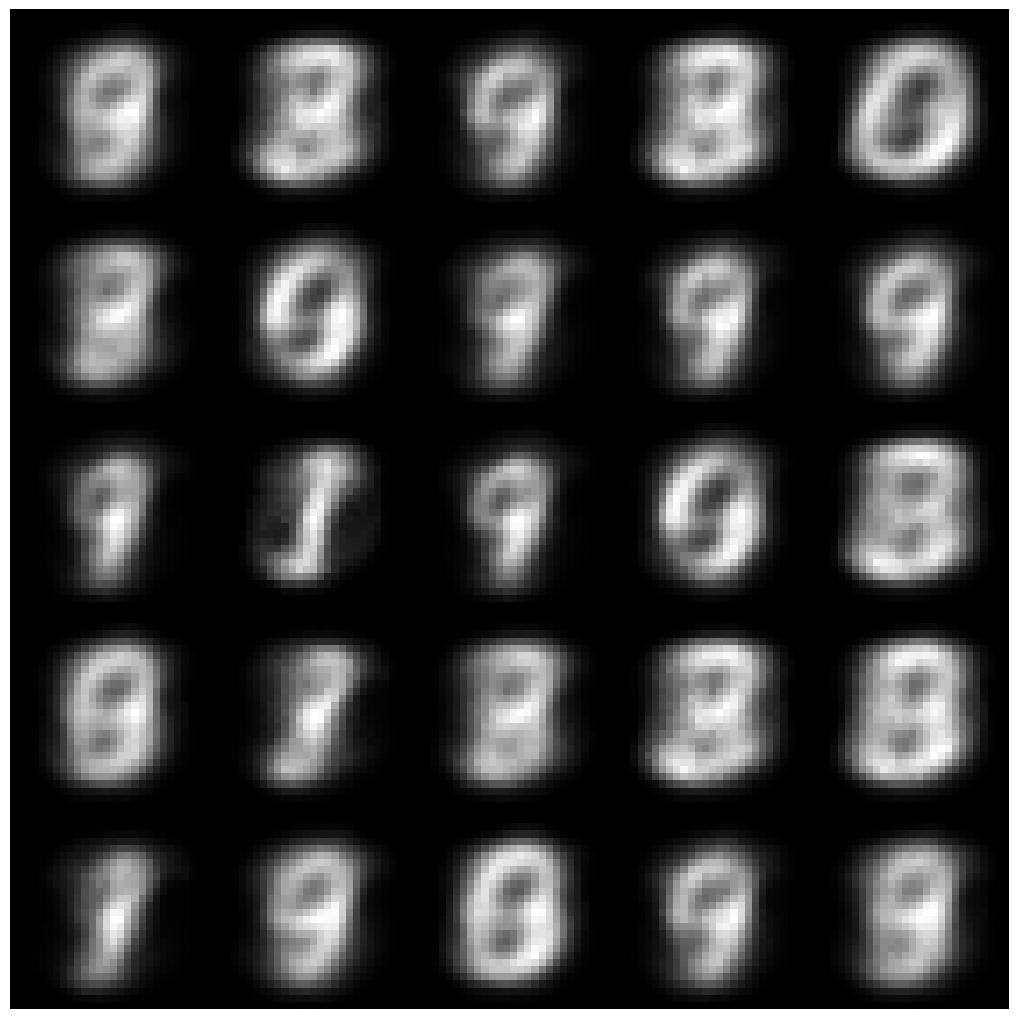

In [39]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))

for i in range(5):
    for j in range(5):
        axes[i][j].imshow(generated[i*5 + j].cpu().squeeze(0), cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)


## Visualizing reconstructions


In [40]:
reconstructions = trained_model.reconstruct(eval_dataset[:25].to(device)).detach().cpu()


reconstruction loss: 20.92167854309082 score proxy: -0.1706945151090622 dual proxy: 898.8954467773438 moment loss: 1368.9345703125 lambda reg: 1.658968448638916 reencode loss: 0.27133285999298096


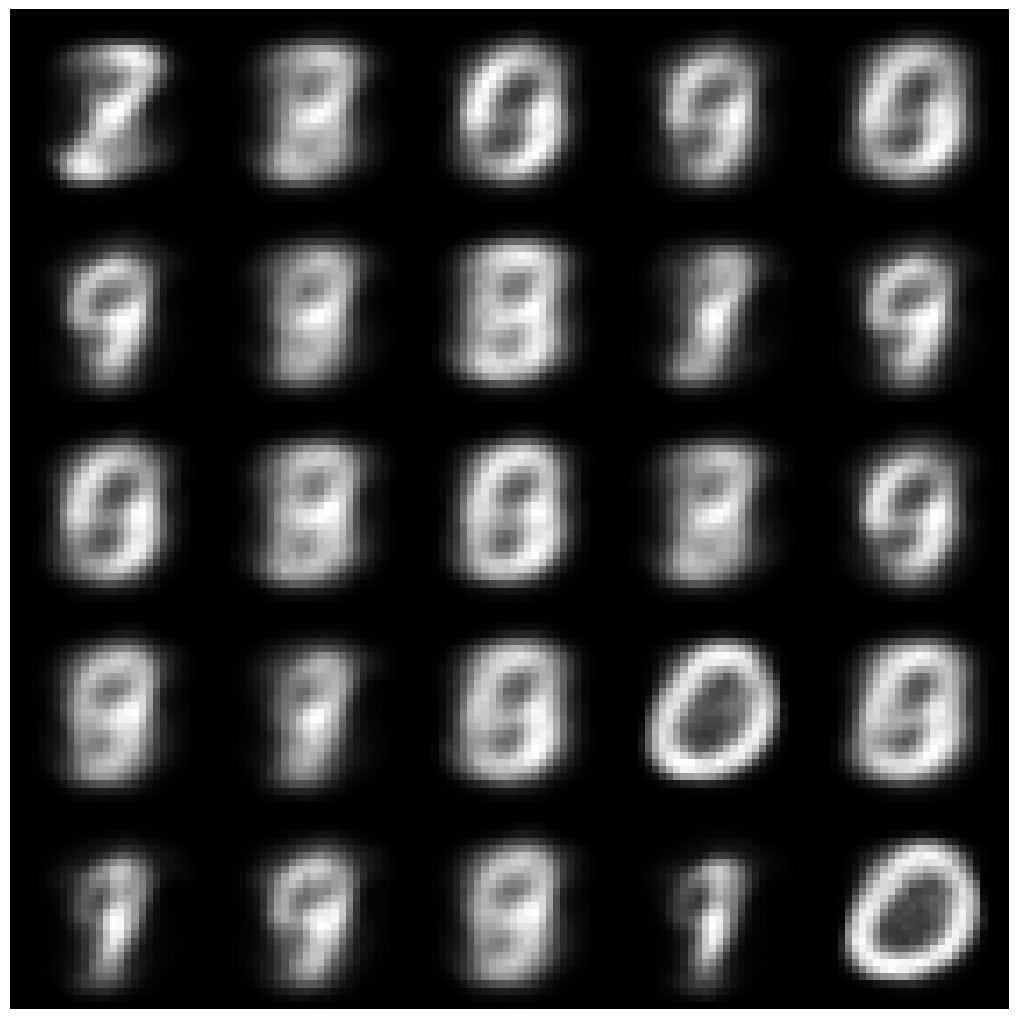

In [41]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))

for i in range(5):
    for j in range(5):
        axes[i][j].imshow(reconstructions[i*5 + j].cpu().squeeze(0), cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)


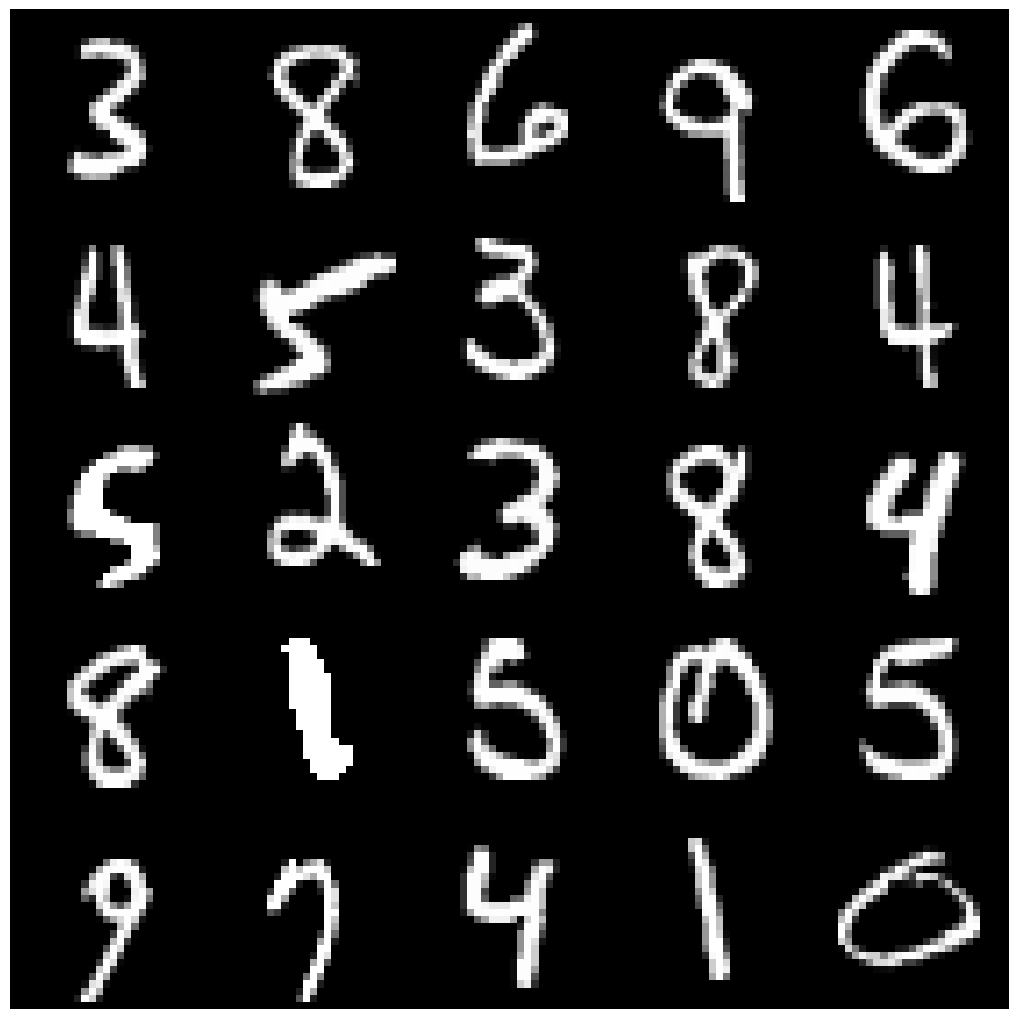

In [42]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))

for i in range(5):
    for j in range(5):
        axes[i][j].imshow(eval_dataset[i*5 + j].cpu().squeeze(0), cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)


## Visualizing interpolations


In [43]:
interpolations = trained_model.interpolate(
    eval_dataset[:5].to(device),
    eval_dataset[5:10].to(device),
    granularity=10
).detach().cpu()


reconstruction loss: 21.348859786987305 score proxy: -0.0008848551660776138 dual proxy: 773.3532104492188 moment loss: 1069.361572265625 lambda reg: 1.6664717197418213 reencode loss: 0.34598201513290405
reconstruction loss: 20.874881744384766 score proxy: -0.000507029180880636 dual proxy: 859.0496215820312 moment loss: 1390.845458984375 lambda reg: 1.5888967514038086 reencode loss: 0.24712520837783813


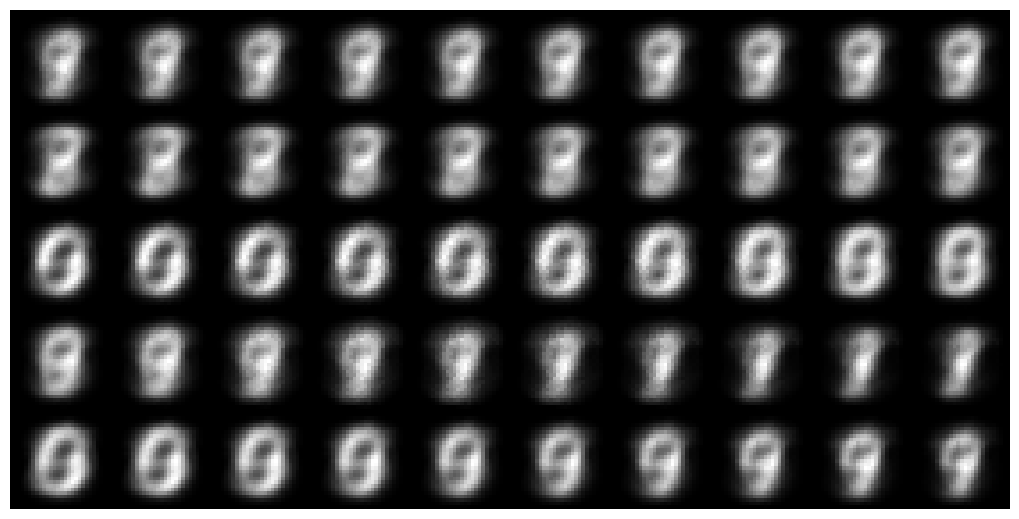

In [44]:
fig, axes = plt.subplots(nrows=5, ncols=10, figsize=(10, 5))

for i in range(5):
    for j in range(10):
        axes[i][j].imshow(interpolations[i, j].cpu().squeeze(0), cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)
